# Tourist Attraction Recognition System

# 1C Group 3

Group Members:
1. Lee Jia Sheng
2. Yeo Zing Le
3. Low Ming Yuan
4. Abhiraami A/P SivaKumar

### Import  the necessary libraries

In [11]:
     pip install opencv-python numpy matplotlib seaborn pandas scikit-learn scikit-image

  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.0-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached contourpy-1.3.2-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.58.4-cp313-cp313-win_amd64.whl.metadata (108 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.2.1-cp313-cp313-win_amd64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.15.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached mat

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import os
import cv2
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

In [7]:
# Set your path to preprocessed images
data_path = Path("C:/Users/YEO/OneDrive/Pictures/TPR DATA/PTR CLEAN PICTURE")

In [8]:
import os
import joblib
import numpy as np
from PIL import Image
import pandas as pd

# Load model and PCA
model = joblib.load('trained_model.pkl')
pca = joblib.load('pca_transformer.pkl')

# Class names mapping (update as needed)
class_names = {
    0: 'A Famosa',
    1: 'Christ Church',
    2: 'Christ The Redeemer Statue',
    3: 'Malacca Clock Tower',
    4: "St Paul's Hill"
}

# Folders to process (update the paths if needed)
folders = [
    'Christ_the_Redeemer_Statue_CROPPED',
    'Malacca Clock Tower - Cropped',
    "St Paul's Hill"
]

IMG_SIZE = 200  # As used in training

def preprocess_image(image_path):
    image = Image.open(image_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    image_array = np.array(image).flatten()
    image_pca = pca.transform(image_array.reshape(1, -1))
    return image_pca

for folder in folders:
    results = []
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            try:
                img_pca = preprocess_image(img_path)
                pred = model.predict(img_pca)[0]
                prob = model.predict_proba(img_pca)[0]
                results.append({
                    'filename': filename,
                    'predicted_class': class_names.get(pred, str(pred)),
                    'confidence': float(prob[pred])
                })
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

    # Save results to CSV
    if results:
        df = pd.DataFrame(results)
        csv_path = os.path.join(folder, 'recognition_results.csv')
        df.to_csv(csv_path, index=False)
        print(f"Results saved to {csv_path}")
    else:
        print(f"No images processed in {folder}")

Folder not found: Christ_the_Redeemer_Statue_CROPPED
Folder not found: Malacca Clock Tower - Cropped
Folder not found: St Paul's Hill


c:\Users\YEO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\YEO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [318]:
# Parameters
IMG_SIZE = 200

# Initialize containers
X = []
y = []
label_map = {}
label_count = 0
samples_per_class = defaultdict(list)

In [319]:
# Group images per class
for building_folder in data_path.iterdir():
    if building_folder.is_dir():
        label = building_folder.name
        if label not in label_map:
            label_map[label] = label_count
            label_count += 1
        class_id = label_map[label]
        for img_file in building_folder.glob("*.png"):
            samples_per_class[class_id].append(str(img_file))

In [320]:
# Select 117 samples per class (or all available if less than 115)
X = []
y = []
original_images = []  # Store original images for visualization
max_per_class = 117

for class_id, files in samples_per_class.items():
    selected_files = random.sample(files, min(max_per_class, len(files)))
    for img_path in selected_files:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            original_images.append((img_path, img.copy()))  # Store original for display
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img_resized.flatten())
            y.append(class_id)

In [321]:
X = np.array(X)
y = np.array(y)

In [322]:
# Reverse label_map for printing
id_to_label = {v: k for k, v in label_map.items()}
print("Image count per class (after sampling):")
for class_id in sorted(set(y)):
    print(f"{id_to_label[class_id]}: {np.sum(y == class_id)} images")

Image count per class (after sampling):
A Famosa: 117 images
Christ Church: 117 images
Christ the Redeemer Statue: 117 images
Malacca Clock Tower: 117 images
St Paul's Hill: 117 images


In [323]:
# 1. VISUALIZE SAMPLE PREPROCESSED IMAGES
def show_sample_images(X, y, id_to_label, img_size=200, samples_per_class=3):
    """Display sample preprocessed images from each class"""
    plt.figure(figsize=(15, 12))
    
    classes = sorted(set(y))
    for i, class_id in enumerate(classes):
        # Get indices of images for this class
        class_indices = np.where(y == class_id)[0]
        sample_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)
        
        for j, idx in enumerate(sample_indices):
            plt.subplot(len(classes), samples_per_class, i * samples_per_class + j + 1)
            img = X[idx].reshape(img_size, img_size)
            plt.imshow(img, cmap='gray')
            plt.title(f"{id_to_label[class_id]}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Sample Preprocessed Images (Grayscale, Resized)", y=1.02, fontsize=16)
    plt.show()

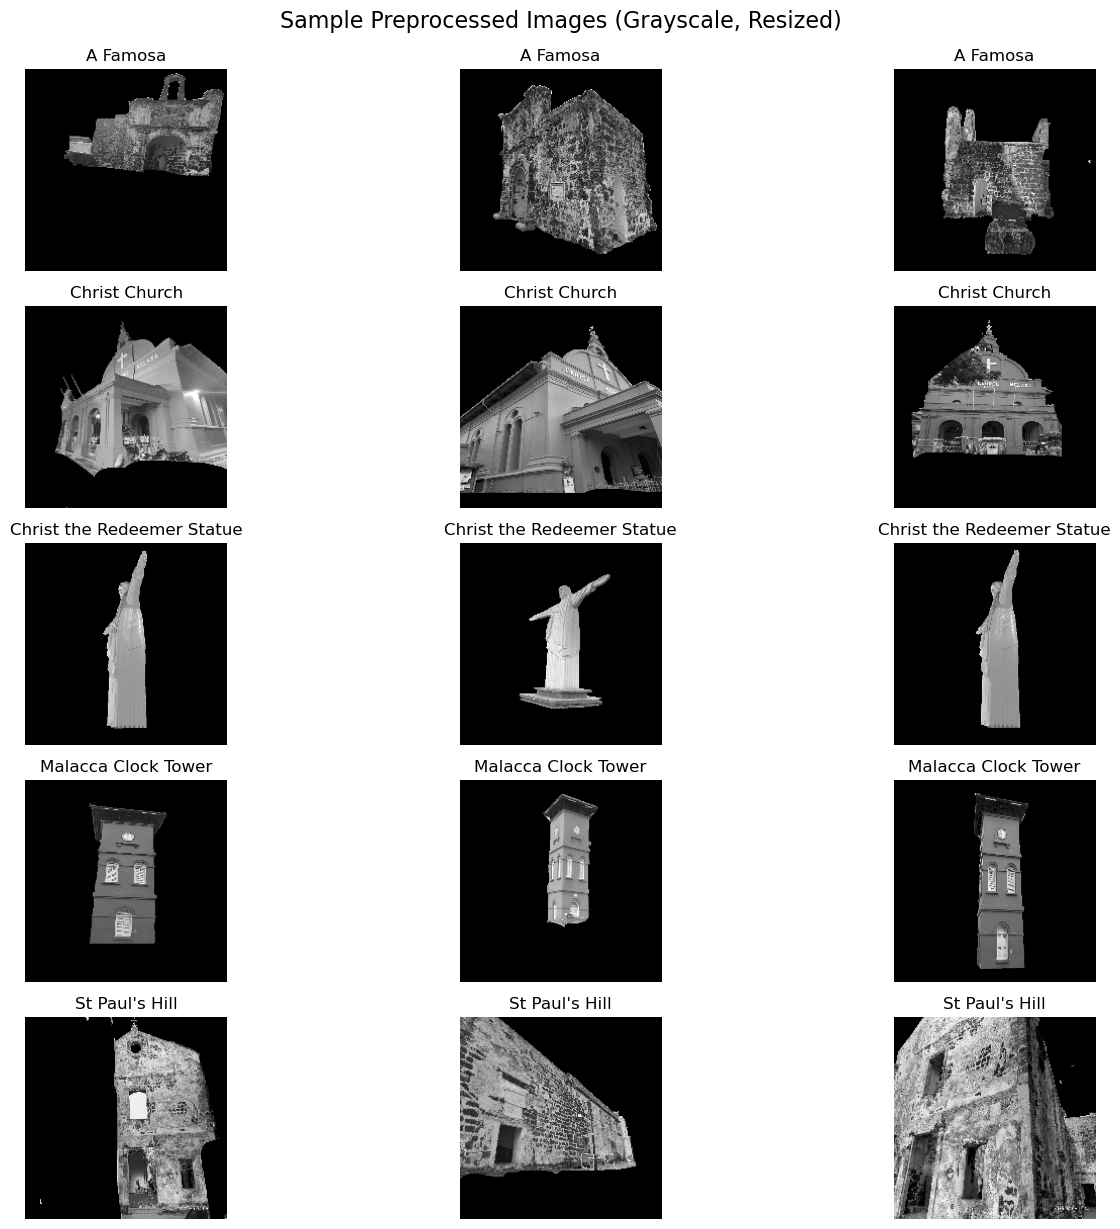

In [324]:
# Show sample preprocessed images
show_sample_images(X, y, id_to_label, IMG_SIZE)

In [325]:
# Apply PCA
pca = PCA(n_components=100)  
X_pca = pca.fit_transform(X)

In [326]:
def plot_pca_visualization(X_pca, y, id_to_label):
    plt.figure(figsize=(12, 8))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    class_ids = sorted(set(y))
    
    for i, class_id in enumerate(class_ids):
        mask = y == class_id
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], label=id_to_label[class_id], alpha=0.6)
    
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Data Visualization in PCA Space (First 2 Components)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

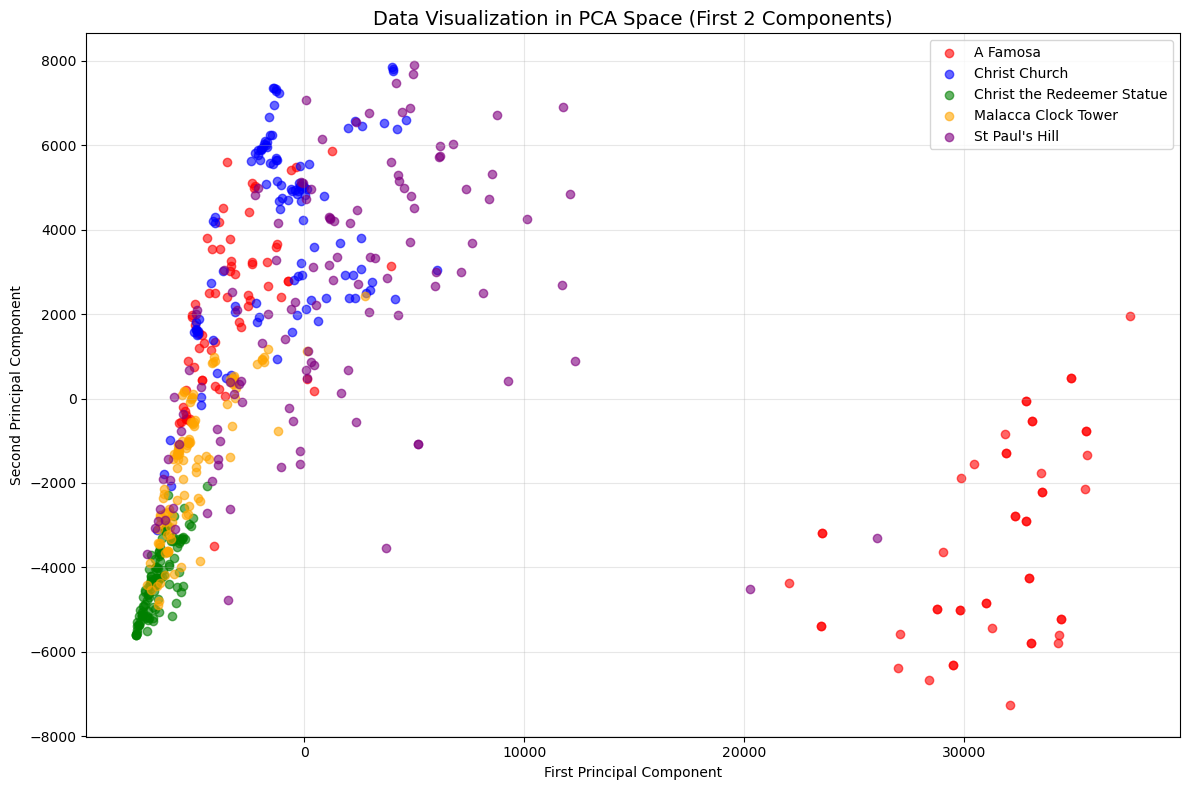

In [327]:
# Plot PCA visualization
plot_pca_visualization(X_pca, y, id_to_label)

In [328]:
# Split into 60% training, 40% testing
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.4, random_state=42, stratify=y)

In [329]:
# Train SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [330]:
# Predict
y_pred = svm.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        47
           1       0.85      0.96      0.90        46
           2       0.98      0.96      0.97        47
           3       0.96      1.00      0.98        47
           4       0.86      0.77      0.81        47

    accuracy                           0.91       234
   macro avg       0.91      0.91      0.90       234
weighted avg       0.91      0.91      0.90       234



In [331]:
# 2. DETAILED METRICS CALCULATION
def calculate_detailed_metrics(y_true, y_pred, id_to_label):
    
    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    # Macro and weighted averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    print("="*80)
    print("DETAILED CLASSIFICATION METRICS")
    print("="*80)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print()
    
    print("Per-Class Metrics:")
    print("-" * 80)
    print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 80)
    
    for i, class_id in enumerate(sorted(set(y_true))):
        class_name = id_to_label[class_id]
        print(f"{class_name:<25} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    
    print("-" * 80)
    print(f"{'Macro Average':<25} {precision_macro:<12.4f} {recall_macro:<12.4f} {f1_macro:<12.4f}")
    print(f"{'Weighted Average':<25} {precision_weighted:<12.4f} {recall_weighted:<12.4f} {f1_weighted:<12.4f}")
    print("="*80)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

In [332]:
# Calculate and display detailed metrics
metrics = calculate_detailed_metrics(y_test, y_pred, id_to_label)

DETAILED CLASSIFICATION METRICS
Overall Accuracy: 0.9060 (90.60%)

Per-Class Metrics:
--------------------------------------------------------------------------------
Class                     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
A Famosa                  0.8889       0.8511       0.8696       47        
Christ Church             0.8462       0.9565       0.8980       46        
Christ the Redeemer Statue 0.9783       0.9574       0.9677       47        
Malacca Clock Tower       0.9592       1.0000       0.9792       47        
St Paul's Hill            0.8571       0.7660       0.8090       47        
--------------------------------------------------------------------------------
Macro Average             0.9059       0.9062       0.9047      
Weighted Average          0.9062       0.9060       0.9047      


In [333]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.905982905982906


In [334]:
# 3. CONFUSION MATRIX VISUALIZATION
def plot_confusion_matrix(y_true, y_pred, id_to_label, normalize=False):
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = 'Normalized Confusion Matrix'
        fmt = '.2f'
    else:
        title = 'Confusion Matrix'
        fmt = 'd'
    
    # Create class labels
    class_labels = [id_to_label[i] for i in sorted(set(y_true))]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label': 'Count' if not normalize else 'Proportion'})
    
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return cm


Confusion Matrix (Raw Counts):


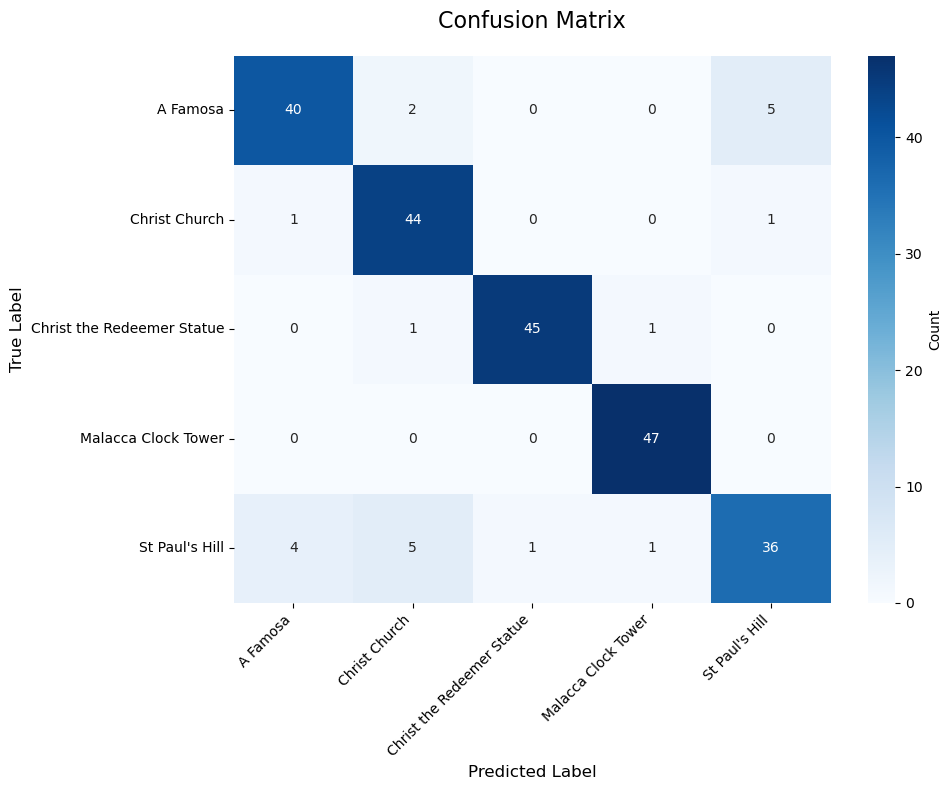

In [335]:
# Plot confusion matrices
print("\nConfusion Matrix (Raw Counts):")
cm_raw = plot_confusion_matrix(y_test, y_pred, id_to_label, normalize=False)

In [336]:
# Print final classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[id_to_label[i] for i in sorted(set(y_test))]))

print(f"\nFinal Model Performance Summary:")
print(f"- Overall Accuracy: {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f"- Macro Average F1-Score: {metrics['f1_macro']:.4f}")
print(f"- Total Test Samples: {len(y_test)}")
print(f"- Number of Classes: {len(set(y))}")


Classification Report:
                            precision    recall  f1-score   support

                  A Famosa       0.89      0.85      0.87        47
             Christ Church       0.85      0.96      0.90        46
Christ the Redeemer Statue       0.98      0.96      0.97        47
       Malacca Clock Tower       0.96      1.00      0.98        47
            St Paul's Hill       0.86      0.77      0.81        47

                  accuracy                           0.91       234
                 macro avg       0.91      0.91      0.90       234
              weighted avg       0.91      0.91      0.90       234


Final Model Performance Summary:
- Overall Accuracy: 0.9060 (90.60%)
- Macro Average F1-Score: 0.9047
- Total Test Samples: 234
- Number of Classes: 5


In [337]:
import joblib

In [340]:
joblib.dump(svm, 'trained_model.pkl')

['trained_model.pkl']

In [341]:
joblib.dump(pca, 'pca_transformer.pkl')

['pca_transformer.pkl']